#Первое задание

1. Скачайте файл с данными по ссылке: https://drive.google.com/file/d/1BO_HrIGapLxxTbbikFQC28Y_DnkWfUbz/view?usp=sharing. Перенесите его в файловую директорию Colab.
2. Создайте директорию, используя команду "mkdir"
3. Распакуйте архив при помощи команды "unzip"
4. Загрузите данные в переменную типа pandas.DataFrame

In [ ]:
!mkdir /content/data_rent

In [ ]:
!unzip /content/data_rent.zip -d /content/data_rent/

Archive:  /content/data_rent.zip
  inflating: /content/data_rent/Dataset Glossary.txt  
  inflating: /content/data_rent/House_Rent_Dataset.csv  


In [ ]:
import pandas as pd
data = pd.read_csv('/content/data_rent/House_Rent_Dataset.csv')

#Второе задание

Проанализируйте состав данных. В качестве подсказки можете воспользоваться файлом $Dataset Glossary.txt$ (в случае необходимости воспользуйтесь переводчиком). Ответьте на вопросы:

1. Сколько всего записей в файле?
2. В каких диапазонах варьируется стоимость аренды домов?
3. Какое самое популярное количество комнат в доме? (мода)
4. В скольких городах (city) представлены дома?
5. Есть ли пропуски в данных?




In [ ]:
#Решение
#1
print("1", len(data))
#2
print("2", data["Rent"].agg(["min", "max"]))
#3
print("3", data["BHK"].value_counts().head(1))
#4
print("4", data["City"].nunique())
#5
print("5", data.isnull().sum())

1 4746
2 min       1200
max    3500000
Name: Rent, dtype: int64
3 BHK
2    2265
Name: count, dtype: int64
4 6
5 Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64


#Третье задание

1. Найдите корреляционную матрицу между числовыми полями в выборке;
2. Сделайте выводы о зависимостях.
3. Есть ли сильная корреляция между стоимостью аренды и другим количественным показателем?

In [ ]:
#Решение
#1
numeric_df = data.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()
print(corr_matrix)


               BHK      Rent      Size  Bathroom
BHK       1.000000  0.369718  0.716145  0.794885
Rent      0.369718  1.000000  0.413551  0.441215
Size      0.716145  0.413551  1.000000  0.740703
Bathroom  0.794885  0.441215  0.740703  1.000000


2. Чем больше комнат, площадь и количество ванных — тем в среднем выше аренда.
3. Сильной корреляции между стоимостью аренды и каким-либо одним количественным показателем нет.

#Четвертое задание

1. Для всех числовых показателей постройте ящик с усами.
2. Есть ли выбросы в данных?
3. Удалите строки, которые являются выбросами.
4. Выполните третье задание еще раз. Есть ли изменения?

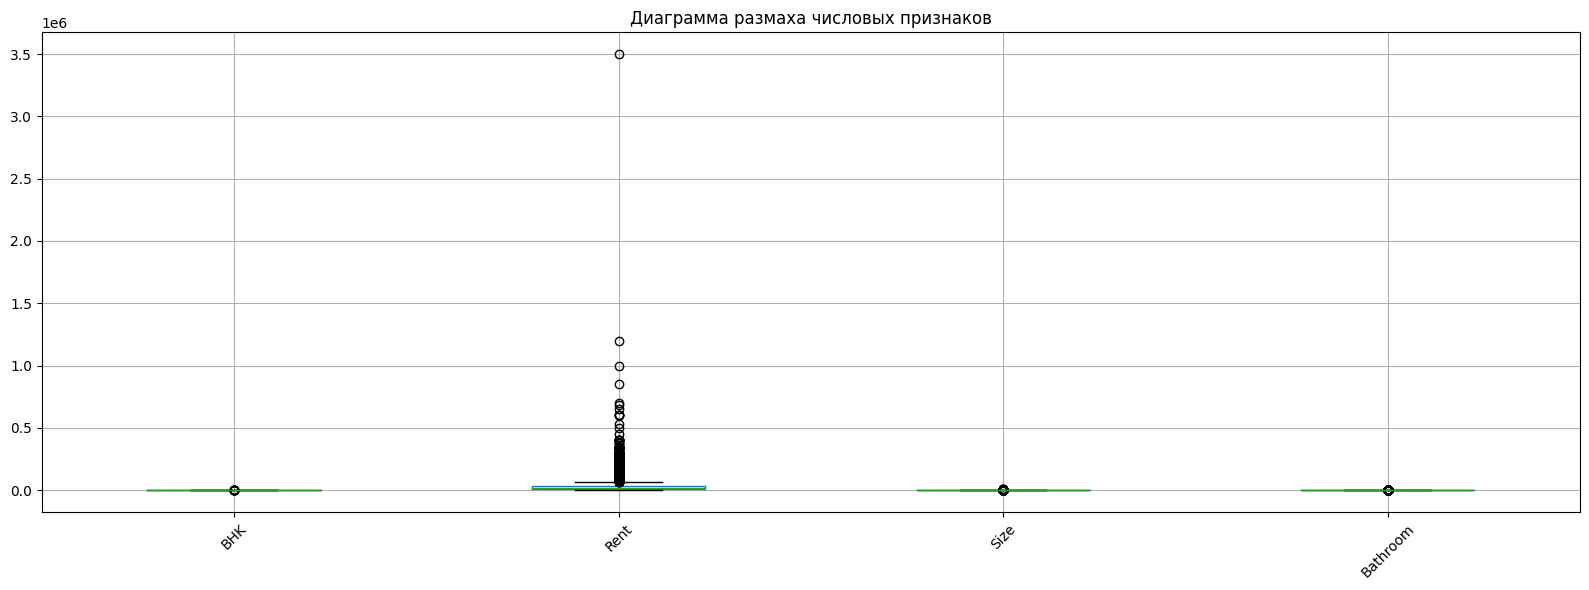

(4078, 12)


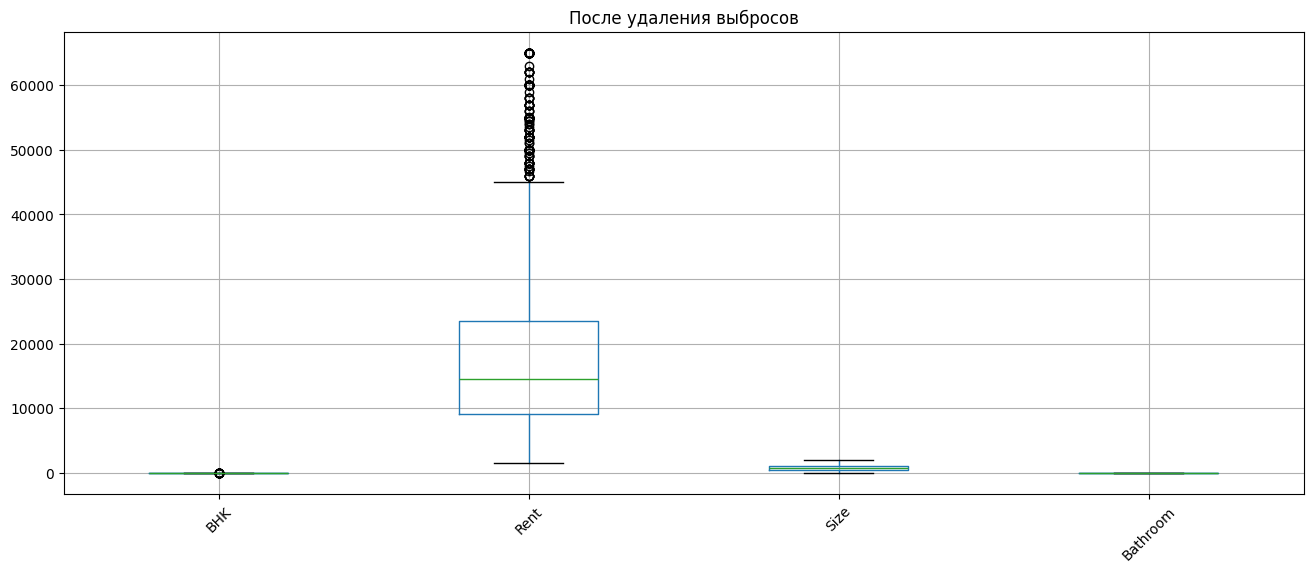


Корреляционная матрица после удаления выбросов:
               BHK      Rent      Size  Bathroom
BHK       1.000000  0.354752  0.677057  0.723999
Rent      0.354752  1.000000  0.320104  0.471460
Size      0.677057  0.320104  1.000000  0.651065
Bathroom  0.723999  0.471460  0.651065  1.000000

Корреляция Rent с другими признаками после очистки:
Bathroom    0.471460
BHK         0.354752
Size        0.320104
Name: Rent, dtype: float64


In [ ]:
#Решение
import matplotlib.pyplot as plt
#1
plt.figure(figsize=(16, 6))
data.select_dtypes(include=['number']).boxplot()
plt.xticks(rotation=45)
plt.title('Диаграмма размаха числовых признаков')
plt.tight_layout()
plt.show()
#2
#Да, особенно в rent и size
#3
num_cols = data.select_dtypes(include=['number']).columns
df_clean = data.copy()

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print(df_clean.shape)
#4
plt.figure(figsize=(16,6))
df_clean.select_dtypes(include=['number']).boxplot()
plt.xticks(rotation=45)
plt.title("После удаления выбросов")
plt.show()

numeric_clean = df_clean.select_dtypes(include=['number'])
corr_clean = numeric_clean.corr()
print("\nКорреляционная матрица после удаления выбросов:")
print(corr_clean)
print("\nКорреляция Rent с другими признаками после очистки:")
print(corr_clean['Rent'].drop('Rent').sort_values(ascending=False))



#Пятое задание

1. Постройте график стоимости аренды от даты размещения;
2. Есть ли тренд на увеличение / уменьшение стоимости с течением времени?
3. Сделайте график стоимости аренды от даты размещений с фильтрами. Возможно, тренд на изменение стоимости присутствует для отдельных категорий домов?

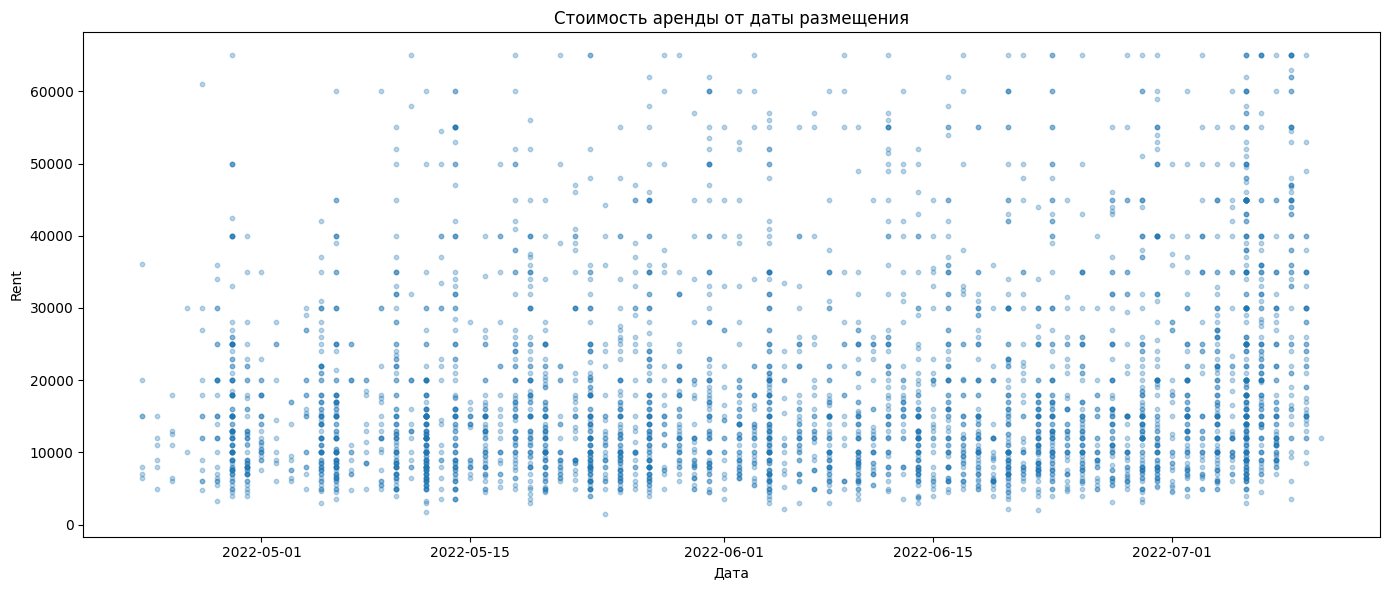

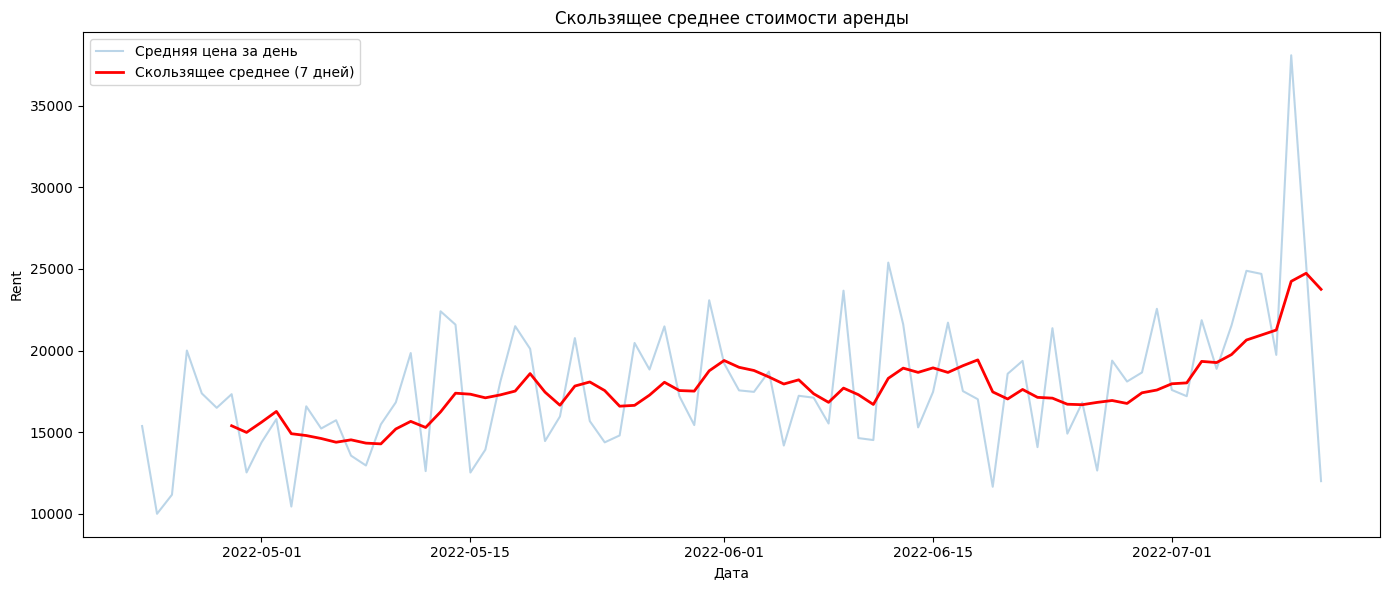

2. На графике скользящего среднего явного тренда на увеличение или уменьшение стоимости не наблюдается.


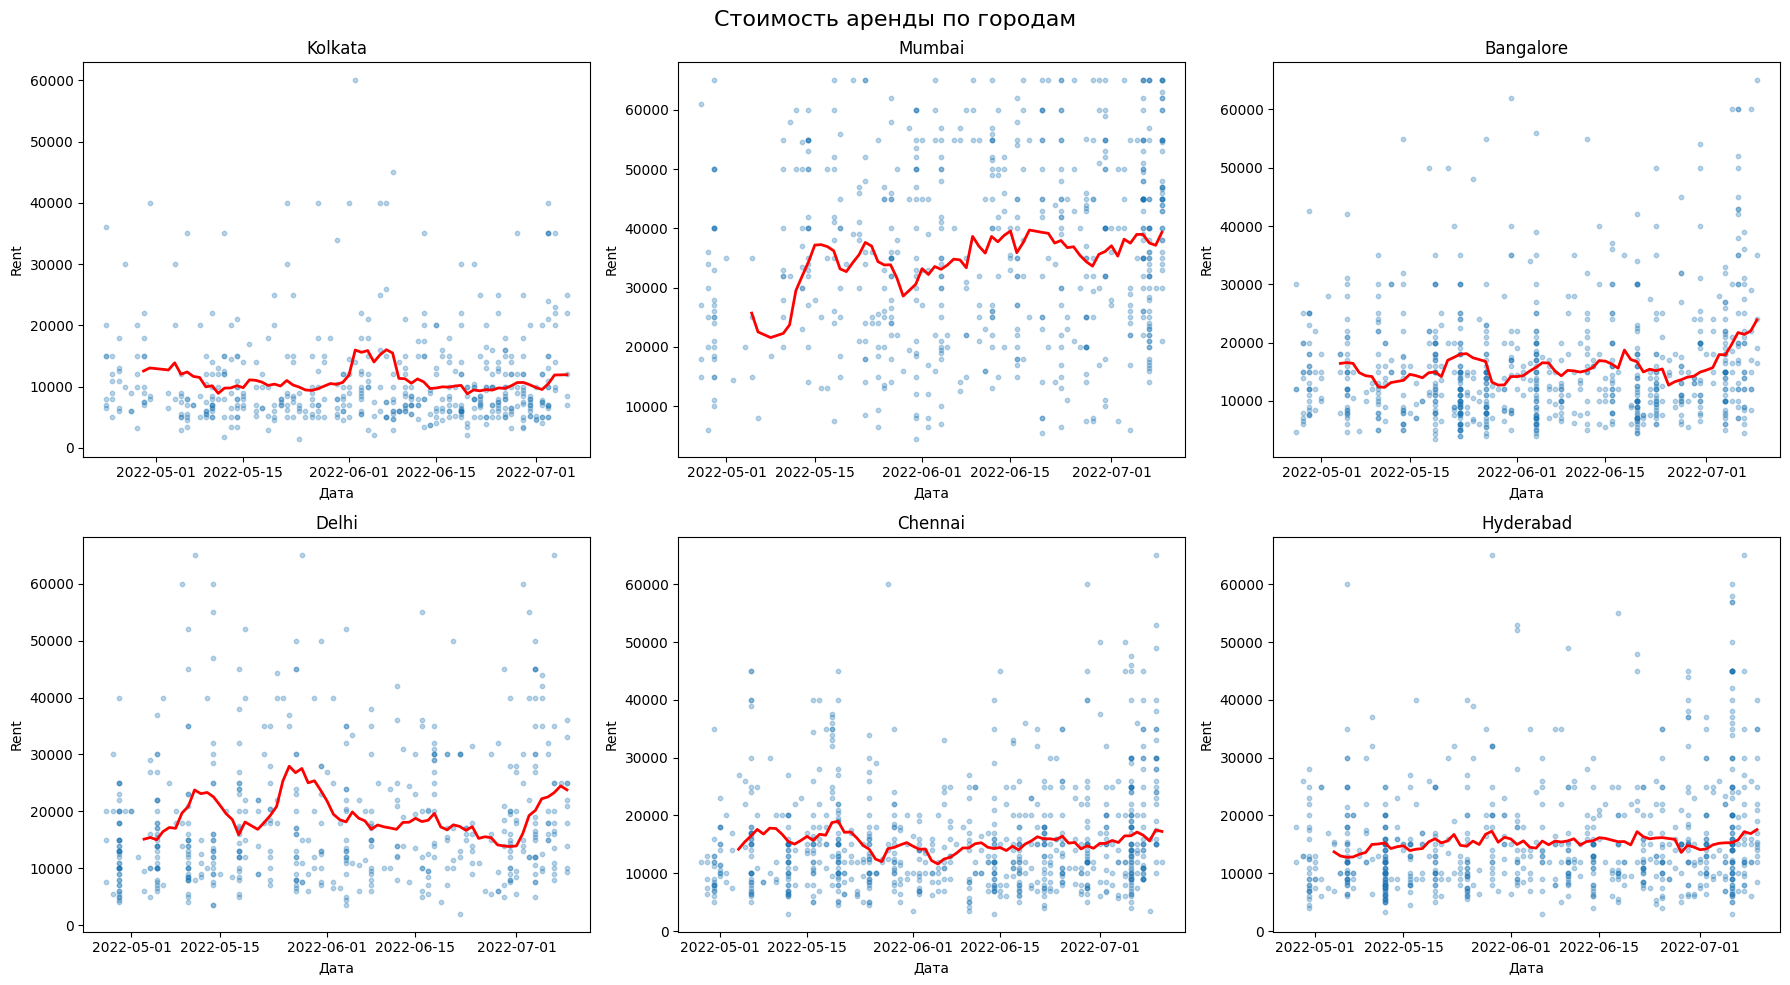

3. На графиках по отдельным городам явный тренд также не наблюдается.


In [ ]:
#Решение

df_clean['Posted On'] = pd.to_datetime(df_clean['Posted On'])

#1
plt.figure(figsize=(14, 6))
plt.scatter(df_clean['Posted On'], df_clean['Rent'], alpha=0.3, s=10)
plt.title('Стоимость аренды от даты размещения')
plt.xlabel('Дата')
plt.ylabel('Rent')
plt.tight_layout()
plt.show()

#2

daily_rent = df_clean.groupby('Posted On')['Rent'].mean().sort_index()
moving_avg = daily_rent.rolling(window=7).mean()

plt.figure(figsize=(14, 6))
plt.plot(daily_rent.index, daily_rent.values, alpha=0.3, label='Средняя цена за день')
plt.plot(moving_avg.index, moving_avg.values, color='red', linewidth=2, label='Скользящее среднее (7 дней)')
plt.title('Скользящее среднее стоимости аренды')
plt.xlabel('Дата')
plt.ylabel('Rent')
plt.legend()
plt.tight_layout()
plt.show()
print("2. На графике скользящего среднего явного тренда на увеличение или уменьшение стоимости не наблюдается.")

#3
cities = df_clean['City'].unique()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, city in enumerate(cities):
    city_data = df_clean[df_clean['City'] == city]
    city_daily = city_data.groupby('Posted On')['Rent'].mean().sort_index()
    city_ma = city_daily.rolling(window=7).mean()

    axes[i].scatter(city_data['Posted On'], city_data['Rent'], alpha=0.3, s=10)
    axes[i].plot(city_ma.index, city_ma.values, color='red', linewidth=2)
    axes[i].set_title(city)
    axes[i].set_xlabel('Дата')
    axes[i].set_ylabel('Rent')

plt.suptitle('Стоимость аренды по городам', fontsize=16)
plt.tight_layout()
plt.show()
print("3. На графиках по отдельным городам явный тренд также не наблюдается.")

#Шестое задание

1. Переведите все категориальные признаки в числовые;

*Примечание*. Категориальные признаки лучше преобразовывать в вектор, так как при преобразовании к числам появляется свойство упорядоченности, что может повлиять на модель линейной регрессии.

2. Постройте модель множественной линейной регрессии для всех признаков, которые есть в данных.

*Примечание*. Вместо даты размещения можно использовать месяц размещения.

3. Оцените значимость коэффициентов линейной регрессии;

4. Методом пошагового исключения удалите все незначимые коэффициенты множественной регрессии;

5. Интерпретируйте построенную модель.

In [ ]:
#Решение
import re
import numpy as np
import statsmodels.api as sm

df_model = df_clean.copy()

#1
def get_floor(x):
    if 'ground' in x.lower() or 'basement' in x.lower():
        return 0
    else:
        return int(x.split()[0])

df_model['Floor_Num'] = df_model['Floor'].apply(get_floor)

df_model['Posted On'] = pd.to_datetime(df_model['Posted On'])
df_model['Month'] = df_model['Posted On'].dt.month

df_model = df_model.drop(columns=['Posted On', 'Floor', 'Area Locality'])

cat_cols = ['Area Type', 'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact']
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True, dtype=int)

for col in df_model.columns:
    if col != 'Rent':
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')
        df_model[col].fillna(df_model[col].median(), inplace=True)

df_model = df_model.dropna(subset=['Rent'])

X = df_model.drop(columns=['Rent'])
y = df_model['Rent']

X = X.astype(float)
y = y.astype(float)

print(f"Количество признаков: {X.shape[1]}")
print(f"Количество наблюдений: {X.shape[0]}")
print(f"Типы данных в X:\n{X.dtypes.unique()}")

#2
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

print("\nНачальная модель:")
print(model.summary())

#3 и 4
features = X.columns.tolist()

while True:
    X_current = sm.add_constant(X[features])
    model = sm.OLS(y, X_current).fit()
    pvalues = model.pvalues.drop('const')

    if pvalues.max() > 0.05:
        worst = pvalues.idxmax()
        features.remove(worst)
        print(f"Исключаем: {worst} (p-value = {pvalues.max():.4f})")
    else:
        break

final_model = sm.OLS(y, sm.add_constant(X[features])).fit()

print("\nИтоговая модель:")
print(final_model.summary())

#5
print(f"\nR² = {final_model.rsquared:.4f} — модель объясняет {final_model.rsquared*100:.1f}% дисперсии Rent")
print("\nЗначимые признаки:")
for feat, coef in final_model.params.drop('const').sort_values(ascending=False).items():
    print(f"  {feat}: {coef:.2f} (p={final_model.pvalues[feat]:.4f})")

/tmp/ipykernel_31136/3566399636.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model[col].fillna(df_model[col].median(), inplace=True)


Количество признаков: 18
Количество наблюдений: 4078
Типы данных в X:
[dtype('float64')]

Начальная модель:
                            OLS Regression Results                            
Dep. Variable:                   Rent   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.691
Method:                 Least Squares   F-statistic:                     506.7
Date:                Mon, 22 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:37:06   Log-Likelihood:                -42080.
No. Observations:                4078   AIC:                         8.420e+04
Df Residuals:                    4059   BIC:                         8.432e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
